In [171]:
import warnings
warnings.filterwarnings("ignore")
import pandas as P

In [172]:
D = P.read_csv("Eco Driving Data.csv")

In [173]:
print(D.columns)

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')


In [174]:
print(D.shape)

(30000, 6)


In [175]:
print(D.info)

<bound method DataFrame.info of        rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
0               2147                    5         14.2              7.87   
1               1703                    3          4.2              9.37   
2               2253                    0          5.5              8.85   
3               2866                    3         21.7              5.87   
4               1636                    2          3.1              6.71   
...              ...                  ...          ...               ...   
29995           1395                    0          6.5              6.50   
29996           2811                    5          6.8              6.84   
29997           1449                    6         15.3              9.93   
29998            500                    3          1.0              6.20   
29999           1639                    2         12.4              7.05   

       acceleration_smoothness  eco_score  
0          

In [176]:
print(D.head)

<bound method NDFrame.head of        rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
0               2147                    5         14.2              7.87   
1               1703                    3          4.2              9.37   
2               2253                    0          5.5              8.85   
3               2866                    3         21.7              5.87   
4               1636                    2          3.1              6.71   
...              ...                  ...          ...               ...   
29995           1395                    0          6.5              6.50   
29996           2811                    5          6.8              6.84   
29997           1449                    6         15.3              9.93   
29998            500                    3          1.0              6.20   
29999           1639                    2         12.4              7.05   

       acceleration_smoothness  eco_score  
0            

In [177]:
print(D.describe)

<bound method NDFrame.describe of        rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
0               2147                    5         14.2              7.87   
1               1703                    3          4.2              9.37   
2               2253                    0          5.5              8.85   
3               2866                    3         21.7              5.87   
4               1636                    2          3.1              6.71   
...              ...                  ...          ...               ...   
29995           1395                    0          6.5              6.50   
29996           2811                    5          6.8              6.84   
29997           1449                    6         15.3              9.93   
29998            500                    3          1.0              6.20   
29999           1639                    2         12.4              7.05   

       acceleration_smoothness  eco_score  
0        

In [178]:
print(D.isnull ().sum ())

rpm_variation              0
harsh_braking_count        0
idling_time                0
fuel_consumption           0
acceleration_smoothness    0
eco_score                  0
dtype: int64


In [179]:
print(D.isnull ().sum ().sum ())

0


In [180]:
print(D[D.isnull ().any (axis = 1)])

Empty DataFrame
Columns: [rpm_variation, harsh_braking_count, idling_time, fuel_consumption, acceleration_smoothness, eco_score]
Index: []


In [181]:
print(D.duplicated ().sum ())

0


In [182]:
print(D.duplicated ().sum ().sum ())

0


In [183]:
print(D[D.duplicated ()])

Empty DataFrame
Columns: [rpm_variation, harsh_braking_count, idling_time, fuel_consumption, acceleration_smoothness, eco_score]
Index: []


In [184]:
print(D.columns)

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')


In [185]:
D.columns = D.columns.str.replace(" ", "_")

In [186]:
D.columns = D.columns.str.strip ()

In [187]:
print(D.columns)

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')


In [188]:
print(D.dtypes)

rpm_variation                int64
harsh_braking_count          int64
idling_time                float64
fuel_consumption           float64
acceleration_smoothness    float64
eco_score                  float64
dtype: object


In [189]:
D["idling_time"] = D["idling_time"].astype (int)
D["fuel_consumption"] = D["fuel_consumption"].astype (int)
D["acceleration_smoothness"] = D["acceleration_smoothness"].astype (int)
D["eco_score"] = D["eco_score"].astype (int)

In [190]:
print(D.dtypes)

rpm_variation              int64
harsh_braking_count        int64
idling_time                int64
fuel_consumption           int64
acceleration_smoothness    int64
eco_score                  int64
dtype: object


In [191]:
print(D.columns)

Index(['rpm_variation', 'harsh_braking_count', 'idling_time',
       'fuel_consumption', 'acceleration_smoothness', 'eco_score'],
      dtype='object')


In [192]:
import matplotlib.pyplot as PLOT

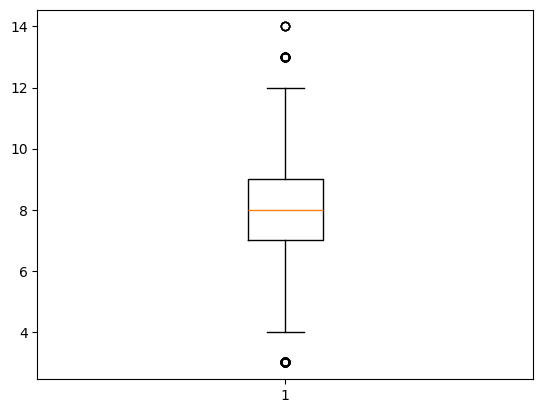

In [193]:
PLOT.boxplot(D["fuel_consumption"])
PLOT.show()

In [194]:
Q1 = D["fuel_consumption"].quantile(0.25)
Q3 = D["fuel_consumption"].quantile(0.75)

In [195]:
IQR = Q3 - Q1
print(IQR)

2.0


In [196]:
Lower = Q1 - 1.5 * IQR
Upper = Q3 + 1.5 * IQR
print(Lower)
print(Upper)

4.0
12.0


In [197]:
Outlier = D[(D["fuel_consumption"] < Lower) | (D["fuel_consumption"] > Upper)]
print(Outlier)

       rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
84              1234                    2            3                 3   
198             1840                    0            3                 3   
395             1471                    0            4                 3   
476             2203                    2            1                 3   
982             1123                    0            9                 3   
...              ...                  ...          ...               ...   
28505           2101                    1            7                 3   
28641           1207                    0            7                 3   
28737           2036                    2            0                 3   
29189           1858                    2           16                 3   
29420           2116                    5           21                13   

       acceleration_smoothness  eco_score  
84                           0         84  

In [198]:
Outlier_Remove = D[(D["fuel_consumption"] >= Lower) & (D["fuel_consumption"] <= Upper)]
print(Outlier_Remove)

       rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
0               2147                    5           14                 7   
1               1703                    3            4                 9   
2               2253                    0            5                 8   
3               2866                    3           21                 5   
4               1636                    2            3                 6   
...              ...                  ...          ...               ...   
29995           1395                    0            6                 6   
29996           2811                    5            6                 6   
29997           1449                    6           15                 9   
29998            500                    3            1                 6   
29999           1639                    2           12                 7   

       acceleration_smoothness  eco_score  
0                            0         42  

In [199]:
print(D.shape)
print(Outlier_Remove.shape)

(30000, 6)
(29878, 6)


In [200]:
from sklearn.preprocessing import StandardScaler

In [201]:
Scaler = StandardScaler()

In [202]:
S = Scaler.fit_transform(D)

In [203]:
print(D.describe)

<bound method NDFrame.describe of        rpm_variation  harsh_braking_count  idling_time  fuel_consumption  \
0               2147                    5           14                 7   
1               1703                    3            4                 9   
2               2253                    0            5                 8   
3               2866                    3           21                 5   
4               1636                    2            3                 6   
...              ...                  ...          ...               ...   
29995           1395                    0            6                 6   
29996           2811                    5            6                 6   
29997           1449                    6           15                 9   
29998            500                    3            1                 6   
29999           1639                    2           12                 7   

       acceleration_smoothness  eco_score  
0        

In [204]:
Save_File = D.to_csv("Eco Driving Data Clean.csv" , index = False)